In [24]:
import pandas as pd
import geopandas as gpd

Load the data

In [25]:
df = pd.read_csv('datasets/model.csv')

gdf = gpd.read_file('datasets/mun_gis_data/mun_map_updated.gpkg') 

Merge 

In [26]:
# select observations for 2024
df_2024 = df[df['year'] == 2024].copy()

map_2024 = pd.merge(df_2024, gdf, on = 'prov', how = 'right')

# dissolve municipal boundaries
gdf_prov = gdf.dissolve(by='prov')

In [27]:
# save provincial boundaries
gdf_prov.to_file("datasets/mun_gis_data/prov_map_updated.gpkg", driver="GPKG", layer="province")

In [28]:
gdf_2024 = gdf_prov.merge(
    df_2024,
    on="prov",
    how="right"
)

In [30]:
gdf_2024.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 97 columns):
 #   Column                                  Non-Null Count  Dtype   
---  ------                                  --------------  -----   
 0   prov                                    110 non-null    object  
 1   geometry                                110 non-null    geometry
 2   CC_UTS                                  110 non-null    float64 
 3   Shape_Leng                              110 non-null    float64 
 4   Shape_Area                              110 non-null    float64 
 5   mun_istat                               110 non-null    object  
 6   year                                    110 non-null    int64   
 7   location                                110 non-null    object  
 8   region                                  110 non-null    object  
 9   prov_buy_min_wgt                        110 non-null    float64 
 10  prov_buy_max_wgt                        11

<Axes: >

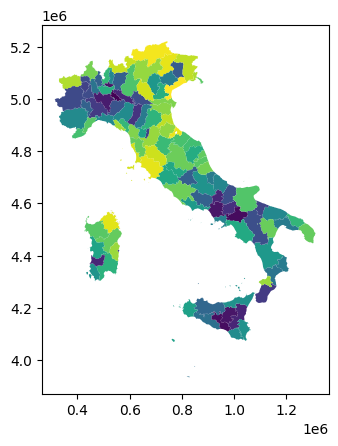

In [32]:
gdf_2024.plot(column = 'tourism_index_vdw')